# Projeto Extra de CCII

------------

Baseado no Artigo "Machine learning approaches for the solution of the Riemann problem in fluid dynamics: a case study" de uma equipe do Los Alamos National Laboratory, o código a seguir busca reproduzir alguns dos resultados do Artigo.

O mesmo busca, de forma resumida, treinar redes neurais para prever soluções de um certo tipo de EDP, dados os parâmetros iniciais.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import newton

In [160]:
# funções para achar a pressão p* com base nas condições iniciais (pág 119)
def F_L(p,gamma,A_L,B_L,c_L,p_L):
    if p>p_L:
        return (p - p_L) * np.sqrt((A_L / (p + B_L)))
        
    if p<= p_L:
        return (2*c_L / (gamma - 1)) * (((p/p_L)**((gamma-1)/(2*gamma))) -1)

def F_R(p,gamma,A_R,B_R,c_R,p_R):
    if p>p_R:
        return (p - p_R) * np.sqrt((A_R / (p + B_R)))
        
    if p<= p_R:
        return (2*c_R / (gamma - 1)) * (((p/p_R)**((gamma-1)/(2*gamma))) -1)


# função da qual iremos achar a raiz
def root_func(p_star,u_R,u_L,F_left,F_right):
    tol = 1e-6
    p_star = max(p_star,tol) # impede de termos pressão negativa, o que faria as funções F_L, F_R retornatem Nan

    return F_left(p_star) + F_right(p_star) + u_R - u_L

############################################
# derivadas para o método de newton-raphson:

def F_L_prime(p,gamma,A_L,B_L,c_L,p_L):
    if p > p_L:
        return np.sqrt(A_L/(B_L + p)) * (1 -  ((p-p_L) / (2*(B_L+p)))) 
    if p<=p_L:
        return (1/(p_L*c_L))*((p/p_L)**((-gamma-1)/(2*gamma)))

def F_R_prime(p,gamma,A_R,B_R,c_R,p_R):
    if p > p_R:
        return np.sqrt(A_R/(B_R + p)) * (1 -  ((p-p_R) / (2*(B_R+p)))) 

    if p<=p_R:
        return (1/(p_R*c_R))*((p/p_R)**((-gamma-1)/(2*gamma)))
        

def root_func_derivative(p_star,F_left_prime,F_right_prime):
    tol = 1e-6
    p_star = max(p_star,tol) # impede de termos pressão negativa, o que faria as funções F_L, F_R retornatem Nan

    return F_left_prime(p_star) + F_right_prime(p_star)

############################################
# funções para calular a densidade intermediária na direita e na esquerda

def G_R(p,gamma,p_R,rho_R):
    if p>p_R:
        num = (p / p_R) + ((gamma - 1)/(gamma + 1)) 
        denom = (((gamma - 1)/(gamma + 1)) * (p / p_R)) + 1
        return rho_R * num/denom
    if p<=p_R:
        return rho_R*(p/p_R)**(1/gamma) 


def G_L(p,gamma,p_L,rho_L):
    if p>p_L:
        num = (p / p_L) + ((gamma - 1)/(gamma + 1)) 
        denom = (((gamma - 1)/(gamma + 1)) * (p / p_L)) + 1
        return rho_L * num/denom
    if p<=p_L:
        return rho_L*(p/p_L)**(1/gamma) 
        

## Sod Problem

### Gerando os Dados

In [32]:
np.random.seed(seed=260)

In [159]:
n_samples = 5000
input_size = 6 # [rho_L, u_L , p_L, rho_R, u_R , p_R]
output_size = 8 # [p_star, u_star, rho_L_star, rho_R_star, S_HL, S_TL, S_HR, S_TR]
X = np.zeros((n_samples+1,input_size))
Y = np.zeros((n_samples+1,output_size))

###########################################
# parâmetros de referência do "Sod Problem"

gamma = 1.4
rho_L_ref = 1
u_L_ref = 0
p_L_ref = 1
rho_R_ref = 0.125
u_R_ref = 0
p_R_ref = 0.1

W_ref = np.array([rho_L_ref, u_L_ref, p_L_ref, rho_R_ref, u_R_ref, p_R_ref])
X[0] = W_ref

eps = 0.9
sample_range = range(n_samples+1)

for sample in tqdm(sample_range):
    if sample == 0:
        rho_L, u_L , p_L, rho_R, u_R , p_R = W_ref

    else:
        rho_L = np.random.uniform(rho_L_ref*(1-eps), rho_L_ref*(1+eps))
        u_L = np.random.uniform(u_L_ref*(1-eps), u_L_ref*(1+eps))
        p_L = np.random.uniform(p_L_ref*(1-eps), p_L_ref*(1+eps))
        rho_R = np.random.uniform(rho_R_ref*(1-eps), rho_R_ref*(1+eps))
        u_R = np.random.uniform(u_R_ref*(1-eps), u_R_ref*(1+eps))
        p_R = np.random.uniform(p_R_ref*(1-eps), p_R_ref*(1+eps))
        
    X[sample] = [rho_L, u_L , p_L, rho_R, u_R , p_R]
    
    A_L = 1 / ((gamma-1)*rho_L)
    B_L = (gamma - 1) * p_L / (gamma + 1)
    c_L = np.sqrt(gamma * p_L / rho_L)
    
    A_R = 1 / ((gamma-1)*rho_R)
    B_R = (gamma - 1) * p_R / (gamma + 1)
    c_R = np.sqrt(gamma * p_R / rho_R)
    
    # funções para resolver o problema de riemman com soluções do Sod problem
    F_L_sod = lambda p: F_L(p,gamma,A_L,B_L,c_L,p_L)
    F_R_sod = lambda p: F_R(p,gamma,A_R,B_R,c_R,p_R)
    F_L_prime_sod = lambda p: F_L_prime(p,gamma,A_L,B_L,c_L,p_L)
    F_R_prime_sod = lambda p: F_R_prime(p,gamma,A_R,B_R,c_R,p_R)
    G_L_sod = lambda p: G_L(p,gamma,p_L,rho_L)
    G_R_sod = lambda p: G_R(p,gamma,p_R,rho_R)
    
    root_func_sod = lambda p_star: root_func(p_star,u_R,u_L,F_L_sod,F_R_sod)
    root_func_derivative_sod = lambda p_star: root_func_derivative(p_star,F_L_prime_sod,F_R_prime_sod)

   
    TOL = 1e-3
    initial_p = max(TOL, 0.5*(p_L + p_R) - (0.125*(u_R - u_L)*(rho_L + rho_R)*(c_L + c_R)))

    p_star_result, r = newton(func=root_func_sod,
                               x0=initial_p,
                               fprime=root_func_derivative_sod,
                               maxiter=10000,
                               tol=1e-3,
                               full_output=True,
                               disp=False)
    

   


    
    u_star = 0.5*(u_L + u_R + F_R_sod(p_star) - F_L_sod(p_star))

    # caso a onda ESQUERDA seja de choque (págs 133 & 134)
    if p_star>p_L:
        rho_L_star = G_L_sod(p_star)
        S_HL = u_L - c_L* np.sqrt( ( ((gamma + 1) / (2*gamma)) * (p_star/p_L) ) + ( (gamma - 1) / (2*gamma) ) )
        S_TL = S_HL + 0.0

    # caso a onda ESQUERDA seja de rarefação (pág 134)    
    if p_star<= p_L:
        rho_L_star = rho_L * (p_star / p_L)**(1/gamma)
        c_L_star = c_L * (p_star/p_L)**((gamma - 1)/(2*gamma))
        S_HL = u_L - c_L
        S_TL = u_star - c_L_star 

    # caso a onda DIREITA seja de choque (págs 133 & 134)
    if p_star>p_R:
        rho_R_star = G_R_sod(p_star)
        S_HR = u_R + c_R* np.sqrt( ( ((gamma + 1) / (2*gamma)) * (p_star/p_R) ) + ( (gamma - 1) / (2*gamma) ) )
        S_TR = S_HR + 0.0

    # caso a onda DIREITA seja de rarefação (pág 134)    
    if p_star<= p_R:
        rho_R_star = rho_R * (p_star / p_R)**(1/gamma)
        c_R_star = c_R * (p_star/p_R)**((gamma - 1)/(2*gamma))
        S_HR = u_R + c_R
        S_TR = u_star + c_R_star 
    
    
    Y[sample] = [p_star, u_star, rho_L_star, rho_R_star, S_HL, S_TL, S_HR, S_TR]

100%|██████████| 5001/5001 [00:40<00:00, 122.13it/s]


### Sensitividade da NN ao tamanho do Output

In [161]:
from sklearn.neural_network import MLPRegressor as MLP

In [162]:
## 1 Neural Network com 8 outputs
NN_all_params = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) ## 1 Neural Network com 8 outputs
NN_all_params = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

##############################################

## 8 Neural Networks com 1 output
NN_p_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_u_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_rho_L_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_rho_R_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_HL = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_TL = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_HR = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_TR = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 


X_train = X[1:]
Y_train = Y[1:]

##############################################

## 8 Neural Networks com 1 output
NN_p_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_u_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_rho_L_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_rho_R_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_HL = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_TL = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_HR = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_TR = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 


X_train = X[1:]
Y_train = Y[1:]

In [163]:
# Treinando as Redes Neurais no caso do Problema Sod

NN_all_params.fit(X_train,Y_train)

NN_p_star.fit(X_train,Y_train[:,0])

NN_u_star.fit(X_train,Y_train[:,1]) 

NN_rho_L_star.fit(X_train,Y_train[:,2])

NN_rho_R_star.fit(X_train,Y_train[:,3])

NN_S_HL.fit(X_train,Y_train[:,4]) 

NN_S_TL.fit(X_train,Y_train[:,5]) 

NN_S_HR.fit(X_train,Y_train[:,6]) 

NN_S_TR.fit(X_train,Y_train[:,7]) 


C:\Users\Vitor\anaconda3_newinstall\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32))

In [164]:
# fazendo a previsão nos parâmetros de referência

W_ref = W_ref.reshape(1,-1)

all_params_predict = NN_all_params.predict(W_ref)

p_star_predict = NN_p_star.predict(W_ref)
u_star_predict = NN_u_star.predict(W_ref)
rho_L_star_predict = NN_rho_L_star.predict(W_ref)
rho_R_star_predict = NN_rho_R_star.predict(W_ref)
S_HL_predict = NN_S_HL.predict(W_ref)
S_TL_predict = NN_S_TL.predict(W_ref)
S_HR_predict = NN_S_HR.predict(W_ref)
S_TR_predict = NN_S_TR.predict(W_ref)

individual_predicts = np.hstack([
    p_star_predict,
    u_star_predict,
    rho_L_star_predict,
    rho_R_star_predict,
    S_HL_predict,
    S_TL_predict,
    S_HR_predict,
    S_TR_predict
])

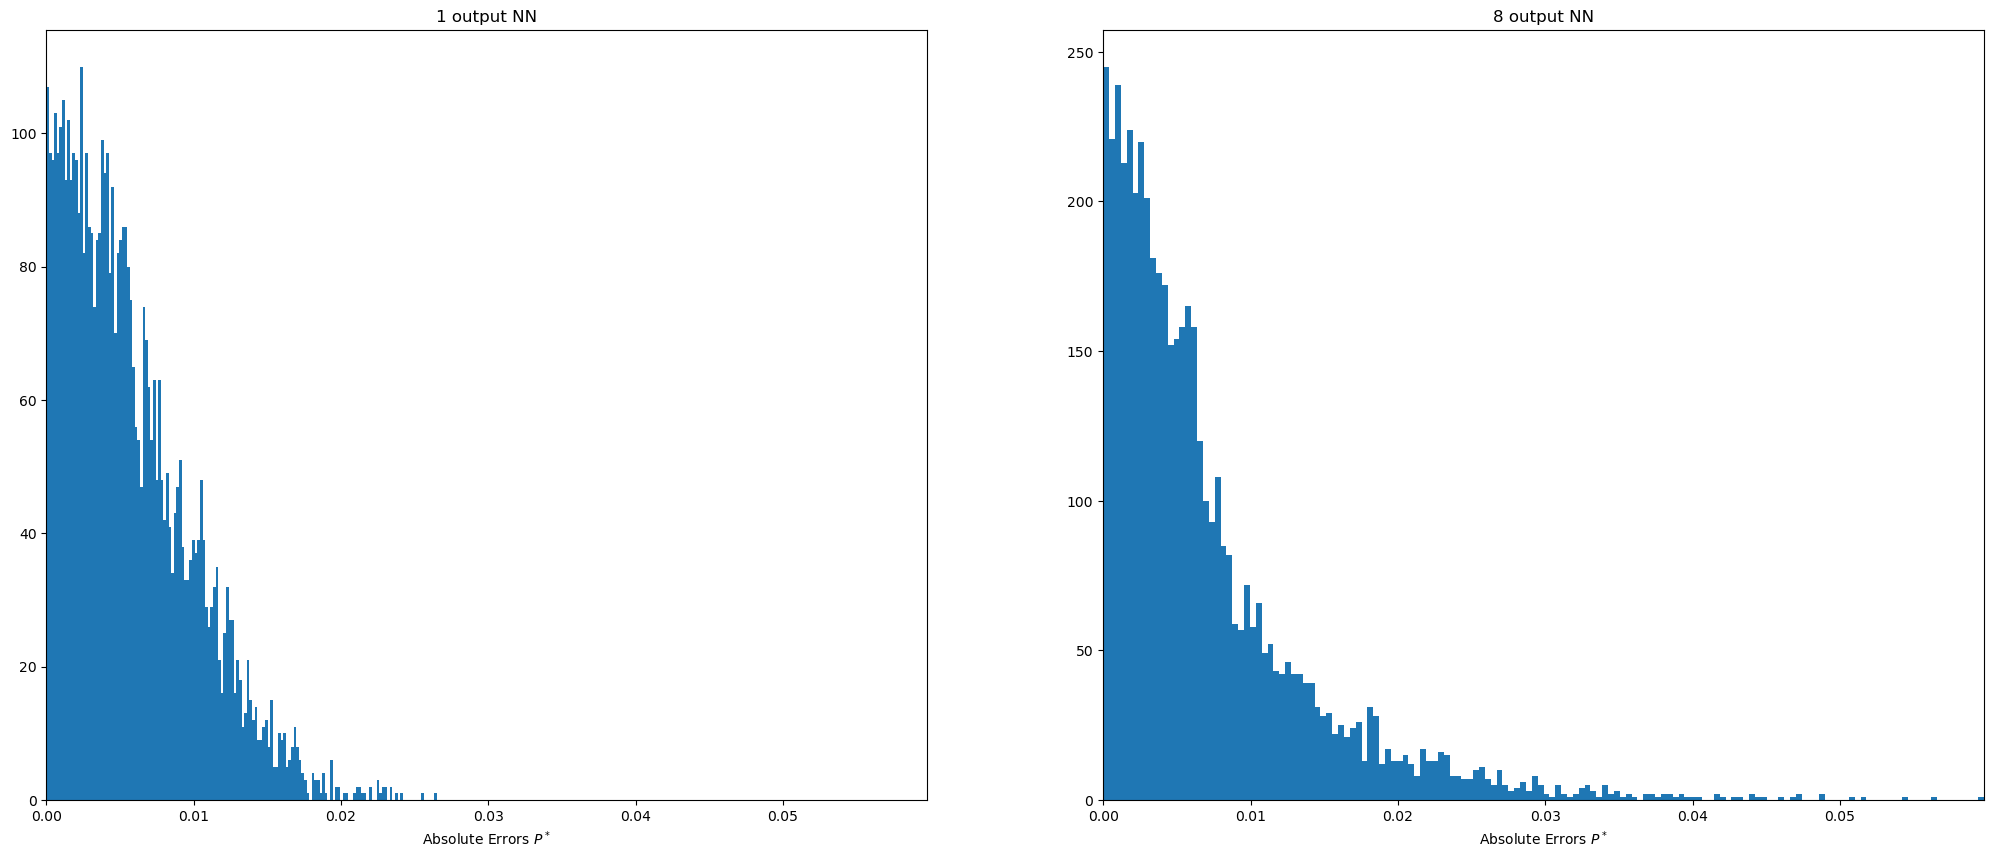

In [165]:
# histograma dos erros

train_p_star_1 = NN_p_star.predict(X_train)
train_p_star_2 = NN_all_params.predict(X_train)[:,0]


pressure_abs_errors_1 = np.abs(Y_train[:,0] - train_p_star_1)
pressure_abs_errors_2 = np.abs(Y_train[:,0] - train_p_star_2)


fig,(ax1,ax2) = plt.subplots(1,2,figsize=(25,10))

ax1.set_xlim(0.0, max(pressure_abs_errors_2))
ax1.set_xlabel("Absolute Errors $P^*$")
ax1.hist(pressure_abs_errors_1,bins=150)
ax1.set_title("1 output NN")

ax2.set_xlim(0.0, max(pressure_abs_errors_2))
ax2.set_xlabel("Absolute Errors $P^*$")
ax2.hist(pressure_abs_errors_2,bins=150)
ax2.set_title("8 output NN")



plt.show()

In [166]:

def W_Lfan_func(x,t, rho_L, u_L, p_L):

    c_L = np.sqrt(gamma * p_L / rho_L)
    
    radicando = ( 2/(gamma+1) ) + ( (gamma-1)/((gamma+1)*c_L) ) * (u_L - x/t)
    
    rho = rho_L * (radicando**(2/(gamma-1)))

    u = ( 2/(gamma + 1) ) * ( c_L + ((gamma-1)/2)*u_L + (x/t) )

    p = p_L * (radicando**(2*gamma/(gamma-1)))

    return [rho, u, p]


def W_Rfan_func(x,t, rho_R, u_R, p_R):

    c_R = np.sqrt(gamma * p_R / rho_R)
    
    radicando = ( 2/(gamma+1) ) - ( (gamma-1)/((gamma+1)*c_R) ) * (u_R - x/t)
    
    rho = rho_R * (radicando**(2/(gamma-1)))

    u = ( 2/(gamma + 1) ) * ( -c_R + ((gamma-1)/2)*u_R + (x/t) )

    p = p_R * (radicando**(2*gamma/(gamma-1)))

    return [rho, u, p]
    


def solution(x, t, initial_params, star_params):
    side = ""
    wave_type = ""
    S = x/t
    rho_L, u_L , p_L, rho_R, u_R , p_R = initial_params
    p_star, u_star, rho_L_star, rho_R_star,S_HL, S_TL, S_HR, S_TR = star_params
    

    W_L = np.array([rho_L, u_L, p_L])
    W_star_L = np.array([rho_L_star, u_star, p_star])
    W_Lfan =  np.array(W_Lfan_func(x,t, rho_L, u_L, p_L))

    W_R = np.array([rho_R, u_R, p_R])
    W_star_R = np.array([rho_R_star, u_star, p_star])
    W_Rfan = np.array(W_Rfan_func(x,t, rho_R, u_R, p_R))
    
    
    # Decide de qual lado está o ponto
    if S < u_star:
        side = "left"
        p_X = p_L
        
    if S >= u_star:
        side = "right"
        p_X = p_R
        
    
    # Decide qual é o tipo de onda
    if p_star > p_X:
        wave_type = side + " shock"
        
    if p_star <= p_X:
        wave_type = side + " rarefaction"

    #####################################

    # Lado Esquerdo
    if wave_type == "left shock":
        
        if S > S_TL: 
            return W_star_L
        else:
            return W_L
    
    if wave_type == "left rarefaction":
        
        if S < S_HL:
            return W_L
        if S > S_TL:
            return W_star_L
        else:
            return W_Lfan


    # Lado Direito
    if wave_type == "right shock":
        
        if S <= S_TR: 
            return W_star_R
        else:
            return W_R
    
    if wave_type == "right rarefaction":
        
        if S <= S_TR:
            return W_star_R
        if S >= S_HR:
            return W_R
        else:
            return W_Rfan

    
        


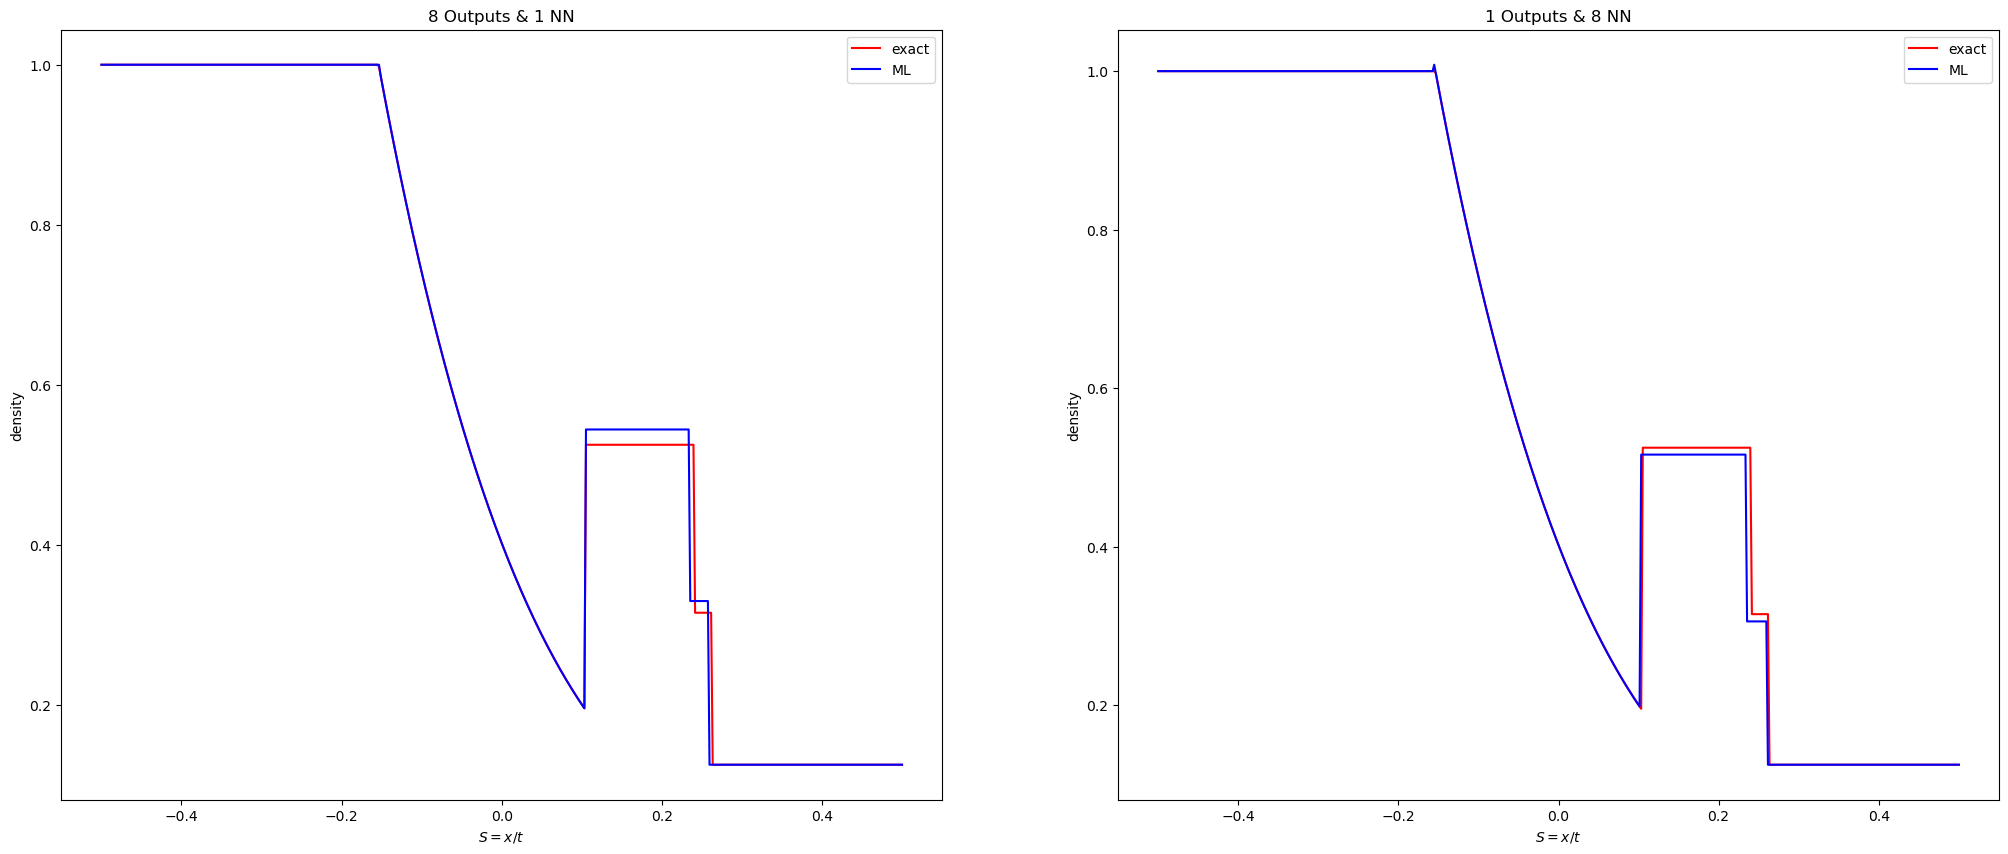

In [174]:
# comparação com a solução real

fig,(ax1,ax2) = plt.subplots(1,2, figsize=(25,10))

t = 0.13

xs = np.linspace(-0.5, 0.5, 500)
rho_vals = [solution(x, t, initial_params = X[0], star_params = Y[0])[0] for x in xs]
rho_vals_predict1 = [solution(x, t, initial_params = X[0], star_params = all_params_predict.flatten())[0] for x in xs]
rho_vals_predict2 = [solution(x, t, initial_params = X[0], star_params = individual_predicts.flatten())[0] for x in xs]

ax1.set_title("8 Outputs & 1 NN")
ax1.plot(xs, rho_vals,color="red",label="exact")
ax1.set_xlabel("$S=x/t$")
ax1.set_ylabel("density")
ax1.plot(xs, rho_vals_predict1,color="blue",label="ML")
ax1.legend()

ax2.set_title("1 Outputs & 8 NN")
ax2.set_xlabel("$S=x/t$")
ax2.set_ylabel("density")
ax2.plot(xs, rho_vals,color="red",label="exact")
ax2.plot(xs, rho_vals_predict2,color="blue",label="ML")
ax2.legend()
plt.show()


------------------

## Le Blanc Problem

### Gerando os Dados

In [175]:
n_samples = 5000
input_size = 6 # [rho_L, u_L , p_L, rho_R, u_R , p_R]
output_size = 8 # [p_star, u_star, rho_L_star, rho_R_star, S_HL, S_TL, S_HR, S_TR]
X = np.zeros((n_samples+1,input_size))
Y = np.zeros((n_samples+1,output_size))

###########################################
# parâmetros de referência do "Sod Problem"

gamma = 5/3
rho_L_ref = 1
u_L_ref = 0
p_L_ref = 0.1 * (gamma-1)
rho_R_ref = 1e-3
u_R_ref = 0
p_R_ref = (gamma-1)*rho_R_ref*1e-7

W_ref = np.array([rho_L_ref, u_L_ref, p_L_ref, rho_R_ref, u_R_ref, p_R_ref])
X[0] = W_ref

eps = 0.9
sample_range = range(n_samples+1)

for sample in tqdm(sample_range):
    if sample == 0:
        rho_L, u_L , p_L, rho_R, u_R , p_R = W_ref

    else:
        rho_L = np.random.uniform(rho_L_ref*(1-eps), rho_L_ref*(1+eps))
        u_L = np.random.uniform(u_L_ref*(1-eps), u_L_ref*(1+eps))
        p_L = np.random.uniform(p_L_ref*(1-eps), p_L_ref*(1+eps))
        rho_R = np.random.uniform(rho_R_ref*(1-eps), rho_R_ref*(1+eps))
        u_R = np.random.uniform(u_R_ref*(1-eps), u_R_ref*(1+eps))
        p_R = np.random.uniform(p_R_ref*(1-eps), p_R_ref*(1+eps))
        
    X[sample] = [rho_L, u_L , p_L, rho_R, u_R , p_R]
    
    A_L = 1 / ((gamma-1)*rho_L)
    B_L = (gamma - 1) * p_L / (gamma + 1)
    c_L = np.sqrt(gamma * p_L / rho_L)
    
    A_R = 1 / ((gamma-1)*rho_R)
    B_R = (gamma - 1) * p_R / (gamma + 1)
    c_R = np.sqrt(gamma * p_R / rho_R)
    
    # funções para resolver o problema de riemman com soluções do Sod problem
    F_L_sod = lambda p: F_L(p,gamma,A_L,B_L,c_L,p_L)
    F_R_sod = lambda p: F_R(p,gamma,A_R,B_R,c_R,p_R)
    F_L_prime_sod = lambda p: F_L_prime(p,gamma,A_L,B_L,c_L,p_L)
    F_R_prime_sod = lambda p: F_R_prime(p,gamma,A_R,B_R,c_R,p_R)
    G_L_sod = lambda p: G_L(p,gamma,p_L,rho_L)
    G_R_sod = lambda p: G_R(p,gamma,p_R,rho_R)
    
    root_func_sod = lambda p_star: root_func(p_star,u_R,u_L,F_L_sod,F_R_sod)
    root_func_derivative_sod = lambda p_star: root_func_derivative(p_star,F_L_prime_sod,F_R_prime_sod)

   
    TOL = 1e-3
    initial_p = max(TOL, 0.5*(p_L + p_R) - (0.125*(u_R - u_L)*(rho_L + rho_R)*(c_L + c_R)))

    p_star_result, r = newton(func=root_func_sod,
                               x0=initial_p,
                               fprime=root_func_derivative_sod,
                               maxiter=10000,
                               tol=1e-3,
                               full_output=True,
                               disp=False)
    

   


    
    u_star = 0.5*(u_L + u_R + F_R_sod(p_star) - F_L_sod(p_star))

    # caso a onda ESQUERDA seja de choque (págs 133 & 134)
    if p_star>p_L:
        rho_L_star = G_L_sod(p_star)
        S_HL = u_L - c_L* np.sqrt( ( ((gamma + 1) / (2*gamma)) * (p_star/p_L) ) + ( (gamma - 1) / (2*gamma) ) )
        S_TL = S_HL + 0.0

    # caso a onda ESQUERDA seja de rarefação (pág 134)    
    if p_star<= p_L:
        rho_L_star = rho_L * (p_star / p_L)**(1/gamma)
        c_L_star = c_L * (p_star/p_L)**((gamma - 1)/(2*gamma))
        S_HL = u_L - c_L
        S_TL = u_star - c_L_star 

    # caso a onda DIREITA seja de choque (págs 133 & 134)
    if p_star>p_R:
        rho_R_star = G_R_sod(p_star)
        S_HR = u_R + c_R* np.sqrt( ( ((gamma + 1) / (2*gamma)) * (p_star/p_R) ) + ( (gamma - 1) / (2*gamma) ) )
        S_TR = S_HR + 0.0

    # caso a onda DIREITA seja de rarefação (pág 134)    
    if p_star<= p_R:
        rho_R_star = rho_R * (p_star / p_R)**(1/gamma)
        c_R_star = c_R * (p_star/p_R)**((gamma - 1)/(2*gamma))
        S_HR = u_R + c_R
        S_TR = u_star + c_R_star 
    
    
    Y[sample] = [p_star, u_star, rho_L_star, rho_R_star, S_HL, S_TL, S_HR, S_TR]

100%|██████████| 5001/5001 [00:01<00:00, 2518.59it/s]


### Sensitividade da NN ao tamanho do Output

In [176]:
## 1 Neural Network com 8 outputs
NN_all_params = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

##############################################

## 8 Neural Networks com 1 output
NN_p_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_u_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_rho_L_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_rho_R_star = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_HL = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_TL = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_HR = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 

NN_S_TR = MLP(hidden_layer_sizes=(64,32),
         activation="relu",
        ) 


X_train = X[1:]
Y_train = Y[1:]

In [179]:
# Treinando as Redes Neurais no caso do Problema Sod

NN_all_params.fit(X_train,Y_train)

NN_p_star.fit(X_train,Y_train[:,0])

NN_u_star.fit(X_train,Y_train[:,1]) 

NN_rho_L_star.fit(X_train,Y_train[:,2])

NN_rho_R_star.fit(X_train,Y_train[:,3])

NN_S_HL.fit(X_train,Y_train[:,4]) 

NN_S_TL.fit(X_train,Y_train[:,5]) 

NN_S_HR.fit(X_train,Y_train[:,6]) 

NN_S_TR.fit(X_train,Y_train[:,7]) 


C:\Users\Vitor\anaconda3_newinstall\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Vitor\anaconda3_newinstall\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Vitor\anaconda3_newinstall\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Vitor\anaconda3_newinstall\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32))

In [180]:
# fazendo a previsão nos parâmetros de referência

W_ref = W_ref.reshape(1,-1)

all_params_predict = NN_all_params.predict(W_ref)

p_star_predict = NN_p_star.predict(W_ref)
u_star_predict = NN_u_star.predict(W_ref)
rho_L_star_predict = NN_rho_L_star.predict(W_ref)
rho_R_star_predict = NN_rho_R_star.predict(W_ref)
S_HL_predict = NN_S_HL.predict(W_ref)
S_TL_predict = NN_S_TL.predict(W_ref)
S_HR_predict = NN_S_HR.predict(W_ref)
S_TR_predict = NN_S_TR.predict(W_ref)

individual_predicts = np.hstack([
    p_star_predict,
    u_star_predict,
    rho_L_star_predict,
    rho_R_star_predict,
    S_HL_predict,
    S_TL_predict,
    S_HR_predict,
    S_TR_predict
])

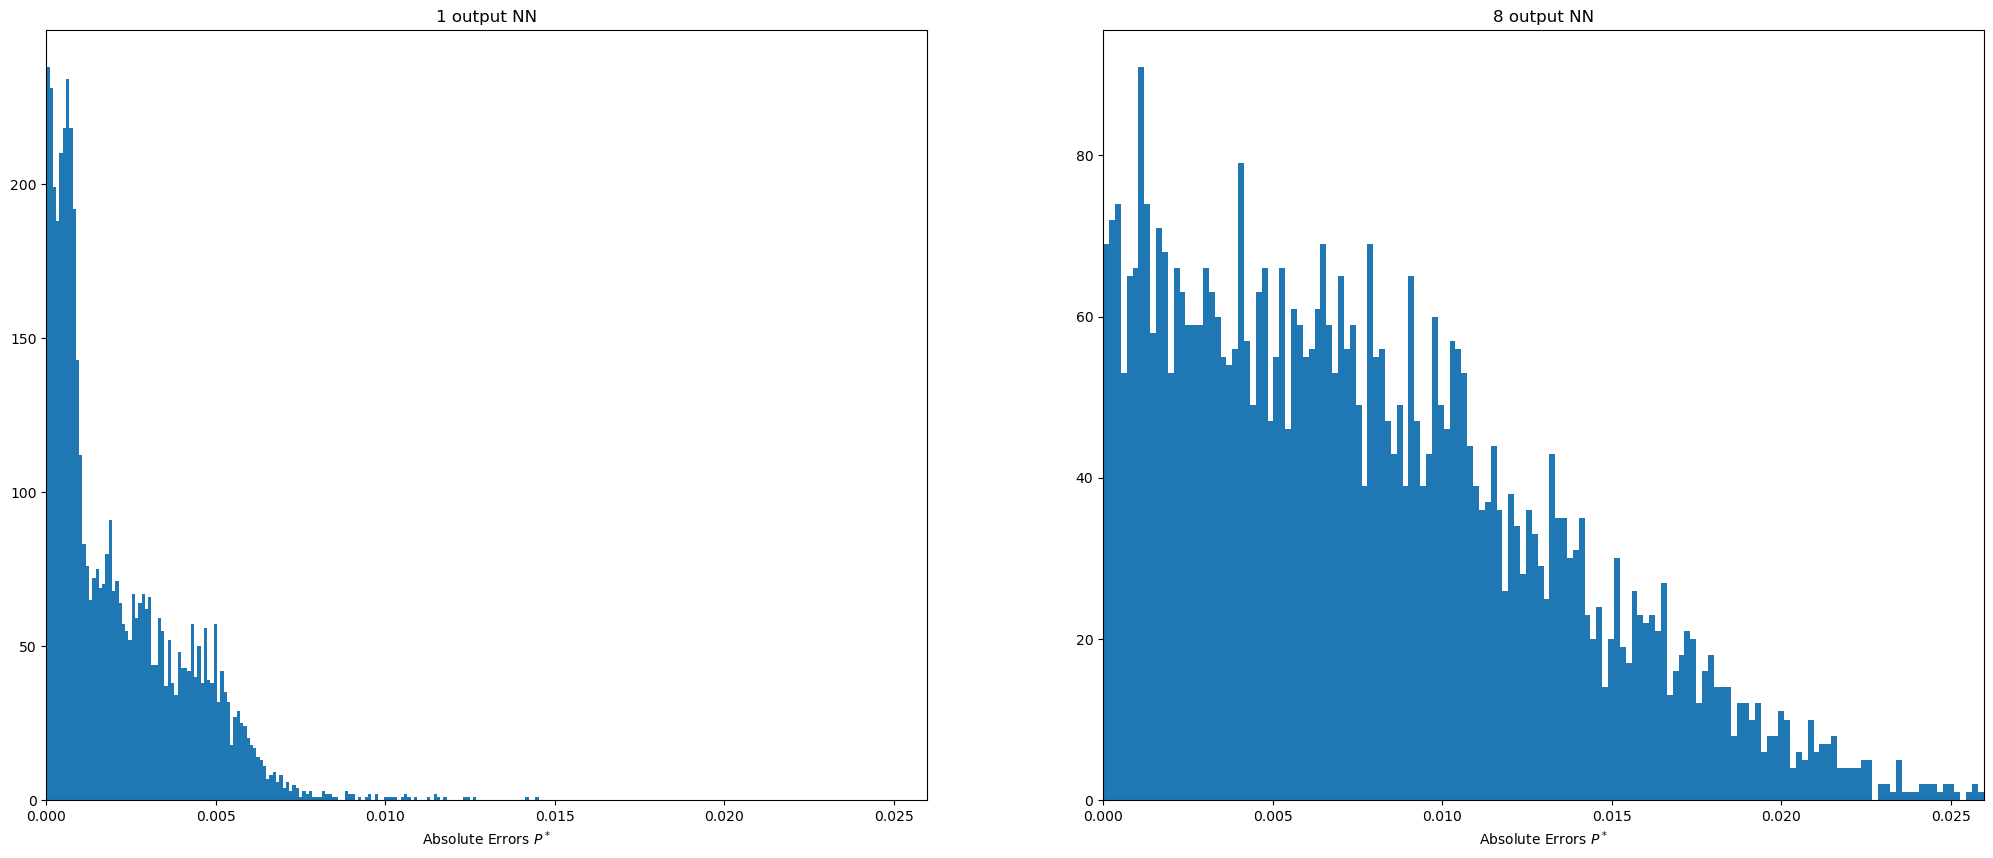

In [181]:
# histograma dos erros

train_p_star_1 = NN_p_star.predict(X_train)
train_p_star_2 = NN_all_params.predict(X_train)[:,0]


pressure_abs_errors_1 = np.abs(Y_train[:,0] - train_p_star_1)
pressure_abs_errors_2 = np.abs(Y_train[:,0] - train_p_star_2)


fig,(ax1,ax2) = plt.subplots(1,2,figsize=(25,10))

ax1.set_xlim(0.0, max(pressure_abs_errors_2))
ax1.set_xlabel("Absolute Errors $P^*$")
ax1.hist(pressure_abs_errors_1,bins=150)
ax1.set_title("1 output NN")

ax2.set_xlim(0.0, max(pressure_abs_errors_2))
ax2.set_xlabel("Absolute Errors $P^*$")
ax2.hist(pressure_abs_errors_2,bins=150)
ax2.set_title("8 output NN")



plt.show()

In [182]:

def W_Lfan_func(x,t, rho_L, u_L, p_L):

    c_L = np.sqrt(gamma * p_L / rho_L)
    
    radicando = ( 2/(gamma+1) ) + ( (gamma-1)/((gamma+1)*c_L) ) * (u_L - x/t)
    
    rho = rho_L * (radicando**(2/(gamma-1)))

    u = ( 2/(gamma + 1) ) * ( c_L + ((gamma-1)/2)*u_L + (x/t) )

    p = p_L * (radicando**(2*gamma/(gamma-1)))

    return [rho, u, p]


def W_Rfan_func(x,t, rho_R, u_R, p_R):

    c_R = np.sqrt(gamma * p_R / rho_R)
    
    radicando = ( 2/(gamma+1) ) - ( (gamma-1)/((gamma+1)*c_R) ) * (u_R - x/t)
    
    rho = rho_R * (radicando**(2/(gamma-1)))

    u = ( 2/(gamma + 1) ) * ( -c_R + ((gamma-1)/2)*u_R + (x/t) )

    p = p_R * (radicando**(2*gamma/(gamma-1)))

    return [rho, u, p]
    


def solution(x, t, initial_params, star_params):
    side = ""
    wave_type = ""
    S = x/t
    rho_L, u_L , p_L, rho_R, u_R , p_R = initial_params
    p_star, u_star, rho_L_star, rho_R_star,S_HL, S_TL, S_HR, S_TR = star_params
    

    W_L = np.array([rho_L, u_L, p_L])
    W_star_L = np.array([rho_L_star, u_star, p_star])
    W_Lfan =  np.array(W_Lfan_func(x,t, rho_L, u_L, p_L))

    W_R = np.array([rho_R, u_R, p_R])
    W_star_R = np.array([rho_R_star, u_star, p_star])
    W_Rfan = np.array(W_Rfan_func(x,t, rho_R, u_R, p_R))
    
    
    # Decide de qual lado está o ponto
    if S < u_star:
        side = "left"
        p_X = p_L
        
    if S >= u_star:
        side = "right"
        p_X = p_R
        
    
    # Decide qual é o tipo de onda
    if p_star > p_X:
        wave_type = side + " shock"
        
    if p_star <= p_X:
        wave_type = side + " rarefaction"

    #####################################

    # Lado Esquerdo
    if wave_type == "left shock":
        
        if S > S_TL: 
            return W_star_L
        else:
            return W_L
    
    if wave_type == "left rarefaction":
        
        if S < S_HL:
            return W_L
        if S > S_TL:
            return W_star_L
        else:
            return W_Lfan


    # Lado Direito
    if wave_type == "right shock":
        
        if S <= S_TR: 
            return W_star_R
        else:
            return W_R
    
    if wave_type == "right rarefaction":
        
        if S <= S_TR:
            return W_star_R
        if S >= S_HR:
            return W_R
        else:
            return W_Rfan

    
        


C:\Users\Vitor\AppData\Local\Temp\ipykernel_27516\3654999343.py:22: RuntimeWarning: invalid value encountered in scalar power
  rho = rho_R * (radicando**(2/(gamma-1)))
C:\Users\Vitor\AppData\Local\Temp\ipykernel_27516\3654999343.py:7: RuntimeWarning: invalid value encountered in scalar power
  rho = rho_L * (radicando**(2/(gamma-1)))


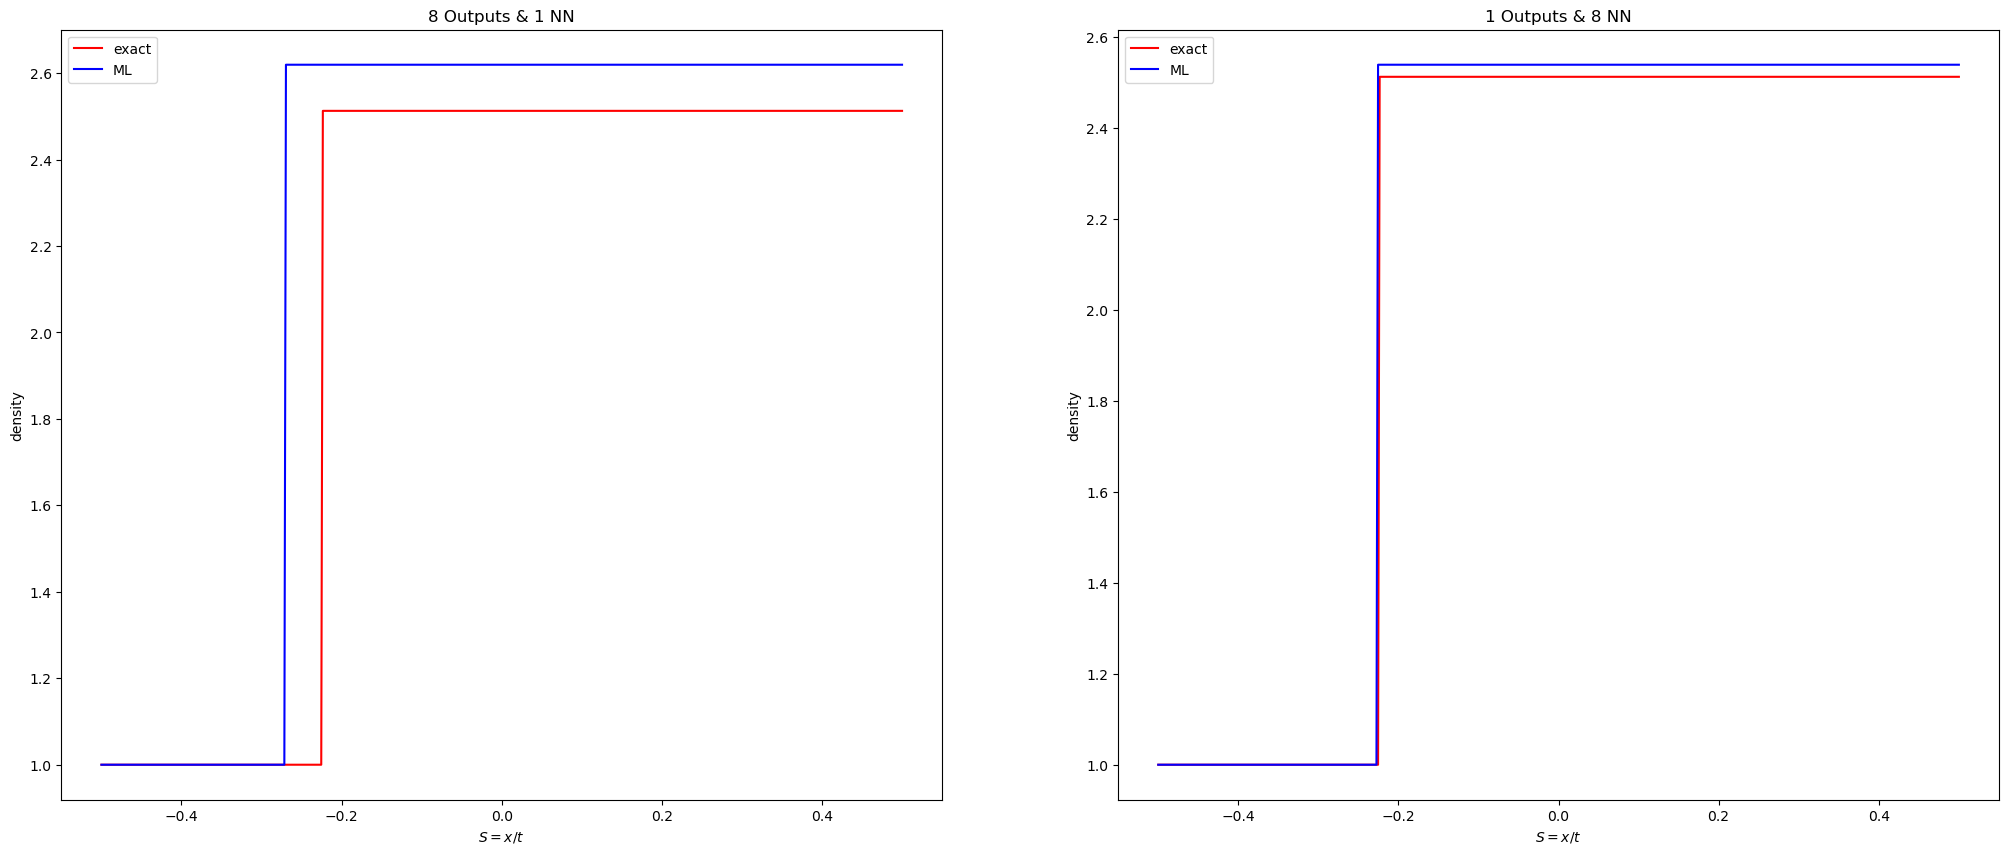

In [185]:
# comparação com a solução real

fig,(ax1,ax2) = plt.subplots(1,2, figsize=(25,10))

t = 0.3

xs = np.linspace(-0.5, 0.5, 500)
rho_vals = [solution(x, t, initial_params = X[0], star_params = Y[0])[0] for x in xs]
rho_vals_predict1 = [solution(x, t, initial_params = X[0], star_params = all_params_predict.flatten())[0] for x in xs]
rho_vals_predict2 = [solution(x, t, initial_params = X[0], star_params = individual_predicts.flatten())[0] for x in xs]

ax1.set_title("8 Outputs & 1 NN")
ax1.plot(xs, rho_vals,color="red",label="exact")
ax1.set_xlabel("$S=x/t$")
ax1.set_ylabel("density")
ax1.plot(xs, rho_vals_predict1,color="blue",label="ML")
ax1.legend()

ax2.set_title("1 Outputs & 8 NN")
ax2.set_xlabel("$S=x/t$")
ax2.set_ylabel("density")
ax2.plot(xs, rho_vals,color="red",label="exact")
ax2.plot(xs, rho_vals_predict2,color="blue",label="ML")
ax2.legend()
plt.show()


## Anotações finais:
- #### Algumas soluções estão um pouco diferentes do artigo, mas acho que foi por algum erro meu na hora de definir as funções e não consegui achar o mesmo a tempo. 
- #### Pelo mesmo motivo não inclui o shock problem. 
- #### Desculpe ter demorado para entregar professor, bom recesso (: